# Gaussian Processes

Gaussian Processes are a statistical tool in Bayesian Learning that, through kernels,
are capable of fitting arbitrary functions. They are characterized through a mean
function $\mu$ and a covariance function $k$.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from pai import GP

mpl.rc_file_defaults()

## Toy Data

In [2]:
rng = np.random.default_rng(42)

x = np.linspace(0, 4 * np.pi, 200).reshape((200, 1))
x_short = np.concatenate([x[:20], x[40:80], x[150:]])
y = np.sin(x_short) + rng.normal(0, 0.2, size=x_short.shape)

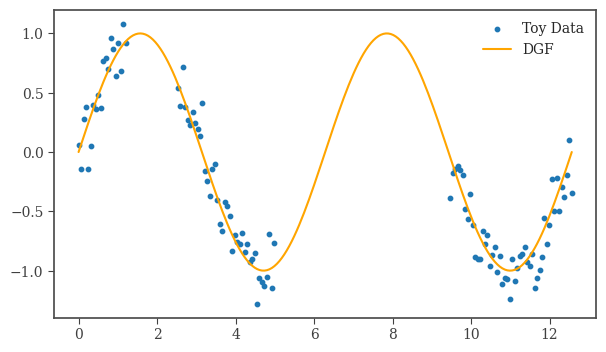

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(x_short, y, label="Toy Data", s=10)
ax.plot(x, np.sin(x), label="DGF", color="orange")
ax.legend()

plt.show()

## Fit a Gaussian Process

The reason why they are so strong is the fact that they are not limited to linear functions.
Furthermore, they not only predict a mean value, but also add uncertainty to their predictions.

In [4]:
gp = GP()

gp = gp.fit(x_short, y)
y_pred, y_cov = gp.predict(x)

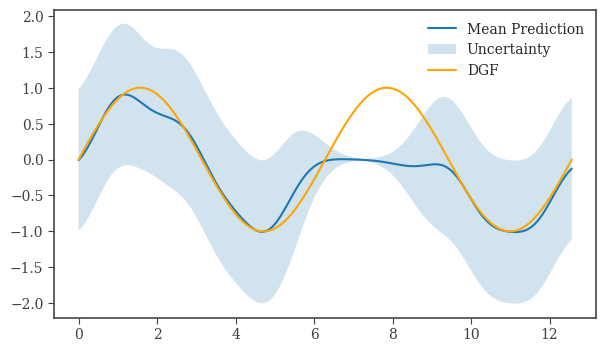

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

y_pred = y_pred.ravel()

std = np.diag(y_cov) ** 0.5
ax.plot(x, y_pred, label="Mean Prediction")
ax.fill_between(x.ravel(), y_pred - std, y_pred + std, label="Uncertainty", alpha=0.2)
ax.plot(x, np.sin(x), label="DGF", color="orange")
ax.legend()

plt.show()

## Kernels

The kernel has a large influence on the prediction results. For example, when using a linear kernel

$$
k(\mathbf{x}, \mathbf{y}) = \mathbf{x}^T\mathbf{y}
$$

the GP is equivalent to Bayesian Linear Regression. The kernel also has an impact on the uncertainty estimation
and the smoothness of the GP.

In [6]:
res = []
for kernel in ["Linear", "RBF", "Exponential"]:
    gp = GP(kernel=kernel.lower())

    gp = gp.fit(x_short, y)
    y_pred, y_cov = gp.predict(x)

    y_std = np.diag(y_cov) ** 0.5

    res.append((kernel, y_pred.ravel(), y_std))

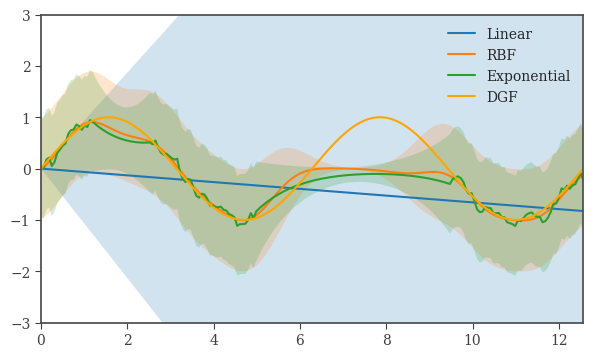

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))

for (label, y_pred, std) in res:
    ax.plot(x, y_pred, label=label)
    ax.fill_between(x.ravel(), y_pred - std, y_pred + std, alpha=0.2)
ax.plot(x, np.sin(x), label="DGF", color="orange")
ax.set_ylim(-3, 3)
ax.set_xlim(0, np.max(x))
ax.legend()

plt.show()